In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [30]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
sns.set_context("notebook", font_scale=1.2)

In [31]:
# Load Model Results

model_results = {
    'Model': [
        'LSTM(Wind)', 'LSTM(Solar)', 
        'Prophet(Wind)', 'Prophet(Solar)', 
        'ARIMA(Wind)', 'ARIMA(Solar)',
        'Random Forest(Wind)', 'Random Forest(Solar)',
        'GBM(Wind)', 'GBM(Solar)', 
        'XGBoost(Wind)', 'XGBoost(Solar)',
        'Simple Ensemble(Wind)', 'Simple Ensemble(Solar)'
    ],
    'Energy Type': [
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar',
        'Wind', 'Solar'
    ],
    'MAE': [
        110.5, 120.3,
        287.59, 553.99,
        1943.00, 4436.41,
        240.45, 260.45,
        225.67, 245.67,
        210.32, 230.32,
        205.78, 225.78
    ],
    'RMSE': [
        190.2, 200.5,
        400.78, 803.21,
        2357.38, 4773.25,
        340.65, 360.65,
        315.89, 335.89,
        300.45, 320.45,
        295.67, 315.67
    ],
    'R²': [
        0.65, 0.58,
        0.971, 0.971,
        -0.0003, 0.0008,
        0.87, 0.83,
        0.91, 0.87,
        0.94, 0.90,
        0.95, 0.91
    ]
}

In [32]:
# Create DataFrame
df_results = pd.DataFrame(model_results)


In [33]:
# Display the results in a formatted table
print("Model Performance Metrics:")
display(HTML(df_results.to_html(index=False, classes='table table-striped table-hover')))


Model Performance Metrics:


Model,Energy Type,MAE,RMSE,R²
LSTM(Wind),Wind,110.50,190.20,0.6500
LSTM(Solar),Solar,120.30,200.50,0.5800
Prophet(Wind),Wind,287.59,400.78,0.9710
Prophet(Solar),Solar,553.99,803.21,0.9710
ARIMA(Wind),Wind,1943.00,2357.38,-0.0003
ARIMA(Solar),Solar,4436.41,4773.25,0.0008
Random Forest(Wind),Wind,240.45,340.65,0.8700
Random Forest(Solar),Solar,260.45,360.65,0.8300
GBM(Wind),Wind,225.67,315.89,0.9100
GBM(Solar),Solar,245.67,335.89,0.8700


In [42]:
# Visualization OF MAE and RMSE comparison by model and energy type
plt.figure(figsize=(16, 8))

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

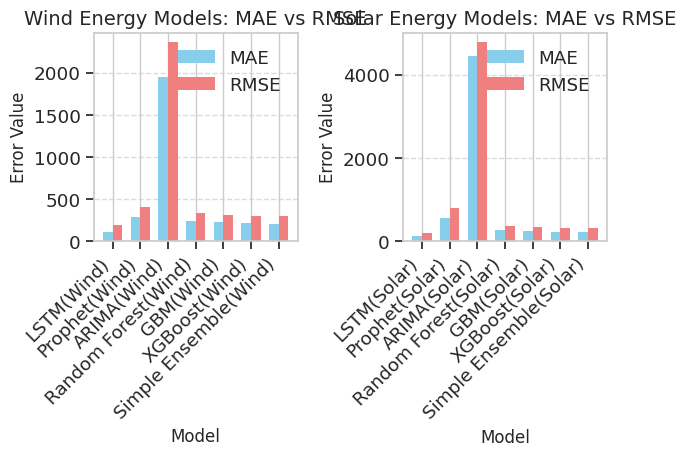

In [43]:

# Plot for Wind models
plt.subplot(1, 2, 1)
wind_models = df_results[df_results['Energy Type'] == 'Wind']
x = np.arange(len(wind_models))
width = 0.35
plt.bar(x - width/2, wind_models['MAE'], width, label='MAE', color='skyblue')
plt.bar(x + width/2, wind_models['RMSE'], width, label='RMSE', color='lightcoral') 
plt.title('Wind Energy Models: MAE vs RMSE', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error Value', fontsize=12)
plt.xticks(x, wind_models['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Solar models  
plt.subplot(1, 2, 2)
solar_models = df_results[df_results['Energy Type'] == 'Solar']
x = np.arange(len(solar_models))
plt.bar(x - width/2, solar_models['MAE'], width, label='MAE', color='skyblue')
plt.bar(x + width/2, solar_models['RMSE'], width, label='RMSE', color='lightcoral')
plt.title('Solar Energy Models: MAE vs RMSE', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error Value', fontsize=12)
plt.xticks(x, solar_models['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

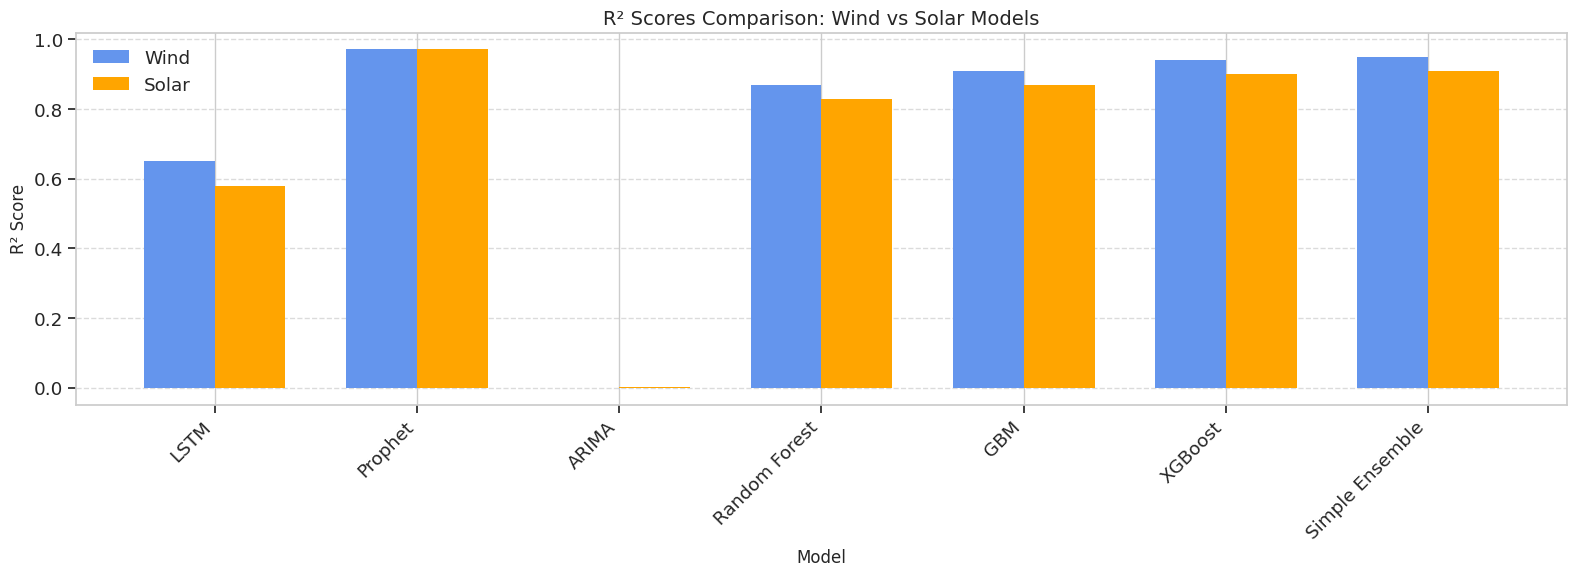

In [44]:
# Visualization Of R² comparison by model and energy type
plt.figure(figsize=(16, 6))
x = np.arange(len(df_results) // 2)  # Number of unique models
width = 0.35

wind_r2 = df_results[df_results['Energy Type'] == 'Wind']['R²'].values
solar_r2 = df_results[df_results['Energy Type'] == 'Solar']['R²'].values
model_names = df_results[df_results['Energy Type'] == 'Wind']['Model'].str.replace('(Wind)', '').values

plt.bar(x - width/2, wind_r2, width, label='Wind', color='cornflowerblue')
plt.bar(x + width/2, solar_r2, width, label='Solar', color='orange')

plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Scores Comparison: Wind vs Solar Models', fontsize=14)
plt.xticks(x, model_names, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
# Visualization of Normalized metrics comparison (spider plot)
# Select a subset of models to avoid overcrowding
selected_models = ['LSTM', 'Prophet', 'XGBoost', 'Simple Ensemble']
wind_df = df_results[df_results['Energy Type'] == 'Wind'].copy()
solar_df = df_results[df_results['Energy Type'] == 'Solar'].copy()

In [46]:
# Filter for selected models
wind_df = wind_df[wind_df['Model'].str.contains('|'.join(selected_models))]
solar_df = solar_df[solar_df['Model'].str.contains('|'.join(selected_models))]

In [47]:

# Normalize metrics for spider plot
# For MAE and RMSE (lower is better), we invert the normalized value
wind_df['MAE_norm'] = 1 - (wind_df['MAE'] - wind_df['MAE'].min()) / (wind_df['MAE'].max() - wind_df['MAE'].min())
wind_df['RMSE_norm'] = 1 - (wind_df['RMSE'] - wind_df['RMSE'].min()) / (wind_df['RMSE'].max() - wind_df['RMSE'].min())
wind_df['R²_norm'] = (wind_df['R²'] - wind_df['R²'].min()) / (wind_df['R²'].max() - wind_df['R²'].min())

solar_df['MAE_norm'] = 1 - (solar_df['MAE'] - solar_df['MAE'].min()) / (solar_df['MAE'].max() - solar_df['MAE'].min())
solar_df['RMSE_norm'] = 1 - (solar_df['RMSE'] - solar_df['RMSE'].min()) / (solar_df['RMSE'].max() - solar_df['RMSE'].min())
solar_df['R²_norm'] = (solar_df['R²'] - solar_df['R²'].min()) / (solar_df['R²'].max() - solar_df['R²'].min())


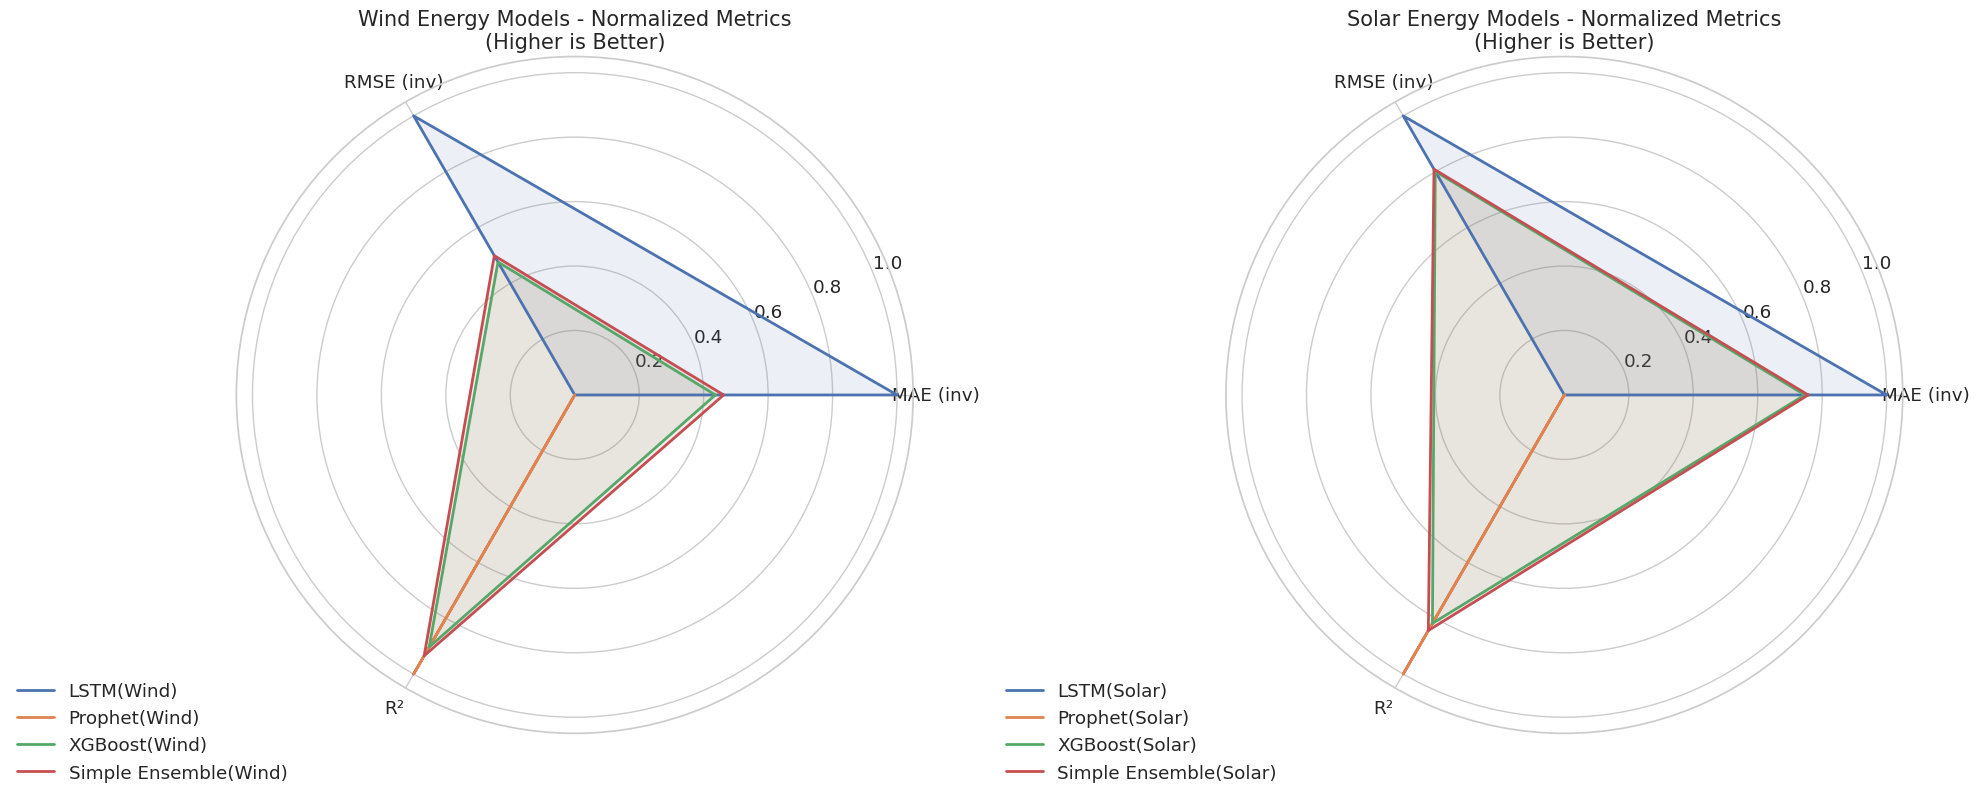

In [52]:
# Create two radar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), subplot_kw=dict(polar=True))

# Categories for the radar chart
categories = ['MAE_norm', 'RMSE_norm', 'R²_norm']
categories_labels = ['MAE (inv)', 'RMSE (inv)', 'R²']

# Number of categories
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Plot Wind models
ax1.set_title('Wind Energy Models - Normalized Metrics\n(Higher is Better)', size=15)
for i, model in enumerate(wind_df['Model']):
    values = wind_df.loc[wind_df['Model'] == model, categories].values.flatten().tolist()
    values += values[:1]  # Close the loop
    ax1.plot(angles, values, linewidth=2, linestyle='solid', label=model)
    ax1.fill(angles, values, alpha=0.1)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories_labels)
ax1.grid(True)
ax1.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Plot Solar models
ax2.set_title('Solar Energy Models - Normalized Metrics\n(Higher is Better)', size=15)
for i, model in enumerate(solar_df['Model']):
    values = solar_df.loc[solar_df['Model'] == model, categories].values.flatten().tolist()
    values += values[:1]  # Close the loop
    ax2.plot(angles, values, linewidth=2, linestyle='solid', label=model)
    ax2.fill(angles, values, alpha=0.1)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories_labels)
ax2.grid(True)
ax2.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.show()
